<a href="https://colab.research.google.com/github/sakshi8435890394-source/Smart-Resume-Screening-and-Candidate-Ranking-System/blob/main/Smart_Resume_Screening_and_Candidate_Ranking_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Resume Screening and Candidate Ranking System

### MBA Business Analytics Project

This project uses Natural Language Processing and a weighted scoring model
to screen resumes, compare candidates with job requirements and rank candidates.

In [2]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from google.colab import files

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving job_description_dataset.csv to job_description_dataset.csv
Saving resume_screening_dataset.csv to resume_screening_dataset (1).csv

Uploaded files:
job_description_dataset.csv
resume_screening_dataset (1).csv


In [5]:
resume_file = 'resume_screening_dataset.csv'
job_file = 'job_description_dataset.csv'

resume_df = pd.read_csv(resume_file)
job_df = pd.read_csv(job_file)

print("Resume Dataset:")
print(resume_df.shape)

print("\nJob Description Dataset:")
print(job_df.shape)

Resume Dataset:
(20, 3)

Job Description Dataset:
(5, 5)


In [6]:
print("===== RESUME DATASET =====")
display(resume_df)

print("\n===== JOB DESCRIPTION DATASET =====")
display(job_df)

===== RESUME DATASET =====


,Candidate_ID,Resume_Text,Category
0,C001,MBA HR graduate with experience in recruitment...,HR Executive
1,C002,MBA Finance graduate with strong knowledge of ...,Finance Analyst
2,C003,BBA graduate with internship experience in rec...,HR Executive
3,C004,MBA HR with 4 years experience in talent acqui...,HR Manager
4,C005,"B.Tech graduate skilled in Python, SQL, machin...",Data Analyst
5,C006,"MBA Business Analytics graduate with Python, S...",Business Analyst
6,C007,"MBA HR graduate with recruitment, onboarding, ...",HR Executive
7,C008,"B.Com graduate with accounting, Tally, GST, ta...",Accountant
8,C009,"MBA Marketing graduate with digital marketing,...",Marketing Executive
9,C010,MBA HR graduate with recruitment and employee ...,HR Executive



===== JOB DESCRIPTION DATASET =====


,Job_ID,Job_Title,Required_Skills,Education,Experience
0,J001,HR Executive,"Recruitment, Talent Acquisition, Employee Enga...",MBA HR,2 years
1,J002,Business Analyst,"Python, SQL, Excel, Power BI, Tableau, Statist...",MBA Business Analytics / equivalent,2 years
2,J003,Data Analyst,"Python, SQL, Machine Learning, Statistics, Pow...",B.Tech / MBA Business Analytics / equivalent,1 year
3,J004,Finance Analyst,"Financial Analysis, Financial Modelling, Excel...",MBA Finance / equivalent,2 years
4,J005,Marketing Executive,"Digital Marketing, SEO, Social Media Marketing...",MBA Marketing / equivalent,2 years


In [7]:
print("===== RESUME DATASET INFORMATION =====")
print(resume_df.info())

print("\n===== MISSING VALUES =====")
print(resume_df.isnull().sum())

print("\n===== DUPLICATES =====")
print("Duplicate resumes:", resume_df.duplicated().sum())

===== RESUME DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Candidate_ID  20 non-null     object
 1   Resume_Text   20 non-null     object
 2   Category      20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes
None

===== MISSING VALUES =====
Candidate_ID    0
Resume_Text     0
Category        0
dtype: int64

===== DUPLICATES =====
Duplicate resumes: 0


In [8]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


resume_df['Clean_Resume'] = resume_df['Resume_Text'].apply(clean_text)

display(resume_df[['Candidate_ID', 'Resume_Text', 'Clean_Resume']])

,Candidate_ID,Resume_Text,Clean_Resume
0,C001,MBA HR graduate with experience in recruitment...,mba hr graduate with experience in recruitment...
1,C002,MBA Finance graduate with strong knowledge of ...,mba finance graduate with strong knowledge of ...
2,C003,BBA graduate with internship experience in rec...,bba graduate with internship experience in rec...
3,C004,MBA HR with 4 years experience in talent acqui...,mba hr with years experience in talent acquisi...
4,C005,"B.Tech graduate skilled in Python, SQL, machin...",b tech graduate skilled in python sql machine ...
5,C006,"MBA Business Analytics graduate with Python, S...",mba business analytics graduate with python sq...
6,C007,"MBA HR graduate with recruitment, onboarding, ...",mba hr graduate with recruitment onboarding pa...
7,C008,"B.Com graduate with accounting, Tally, GST, ta...",b com graduate with accounting tally gst taxat...
8,C009,"MBA Marketing graduate with digital marketing,...",mba marketing graduate with digital marketing ...
9,C010,MBA HR graduate with recruitment and employee ...,mba hr graduate with recruitment and employee ...


In [9]:
job_title = "HR Executive"

selected_job = job_df[
    job_df['Job_Title'].str.lower() == job_title.lower()
].iloc[0]

print("Selected Job:", selected_job['Job_Title'])
print("Required Skills:", selected_job['Required_Skills'])
print("Education:", selected_job['Education'])
print("Experience:", selected_job['Experience'])

Selected Job: HR Executive
Required Skills: Recruitment, Talent Acquisition, Employee Engagement, Employee Relations, HR Analytics, Excel
Education: MBA HR
Experience: 2 years


In [10]:
required_skills = [
    skill.strip().lower()
    for skill in selected_job['Required_Skills'].split(',')
]

print("Required Skills:")
for i, skill in enumerate(required_skills, 1):
    print(i, "-", skill)

Required Skills:
1 - recruitment
2 - talent acquisition
3 - employee engagement
4 - employee relations
5 - hr analytics
6 - excel


In [15]:
def skill_matching(resume, required_skills):
    matched = []

    for skill in required_skills:
        if skill in resume:
            matched.append(skill)

    score = (len(matched) / len(required_skills)) * 100

    return score, matched

In [17]:
skill_results = resume_df['Clean_Resume'].apply(
    lambda x: skill_matching(x, required_skills)
)

resume_df['Skill_Match'] = skill_results.apply(lambda x: x[0])

resume_df['Matched_Skills'] = skill_results.apply(
    lambda x: ", ".join(x[1])
)

display(
    resume_df[
        ['Candidate_ID', 'Skill_Match', 'Matched_Skills']
    ]
)

,Candidate_ID,Skill_Match,Matched_Skills
0,C001,83.333333,"recruitment, talent acquisition, employee enga..."
1,C002,16.666667,excel
2,C003,50.000000,"recruitment, employee engagement, excel"
3,C004,83.333333,"recruitment, talent acquisition, employee rela..."
4,C005,0.000000,
5,C006,16.666667,excel
6,C007,50.000000,"recruitment, employee relations, excel"
7,C008,16.666667,excel
8,C009,0.000000,
9,C010,50.000000,"recruitment, employee engagement, excel"


In [18]:
job_text = f"""
Job Title: {selected_job['Job_Title']}
Required Skills: {selected_job['Required_Skills']}
Education: {selected_job['Education']}
Experience: {selected_job['Experience']}
"""

print(job_text)


Job Title: HR Executive
Required Skills: Recruitment, Talent Acquisition, Employee Engagement, Employee Relations, HR Analytics, Excel
Education: MBA HR
Experience: 2 years



In [19]:
documents = [job_text] + resume_df['Clean_Resume'].tolist()

vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF completed!")
print("Number of features:", len(vectorizer.get_feature_names_out()))

TF-IDF completed!
Number of features: 81


In [20]:
similarity = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:]
).flatten()

resume_df['Similarity_Score'] = similarity * 100

display(
    resume_df[
        ['Candidate_ID', 'Similarity_Score']
    ].sort_values(
        'Similarity_Score',
        ascending=False
    )
)

,Candidate_ID,Similarity_Score
15,C016,61.366010
0,C001,59.865332
3,C004,58.887557
11,C012,49.304985
6,C007,44.908439
9,C010,43.360923
2,C003,20.993460
18,C019,18.864446
5,C006,14.844436
19,C020,9.292874


In [21]:
def education_score(resume):

    if 'mba hr' in resume or 'mba in human resources' in resume:
        return 100

    elif 'mba' in resume or 'bba' in resume:
        return 50

    else:
        return 0


resume_df['Education_Score'] = (
    resume_df['Clean_Resume']
    .apply(education_score)
)

display(
    resume_df[
        ['Candidate_ID', 'Education_Score']
    ]
)

,Candidate_ID,Education_Score
0,C001,100
1,C002,50
2,C003,50
3,C004,100
4,C005,0
5,C006,50
6,C007,100
7,C008,0
8,C009,50
9,C010,100


In [22]:
def experience_score(resume):

    matches = re.findall(
        r'(\d+)\s*years?',
        resume
    )

    if len(matches) == 0:
        return 0

    years = max([int(x) for x in matches])

    if years >= 2:
        return 100

    elif years == 1:
        return 50

    else:
        return 0


resume_df['Experience_Score'] = (
    resume_df['Clean_Resume']
    .apply(experience_score)
)

display(
    resume_df[
        ['Candidate_ID', 'Experience_Score']
    ]
)

,Candidate_ID,Experience_Score
0,C001,0
1,C002,0
2,C003,0
3,C004,0
4,C005,0
5,C006,0
6,C007,0
7,C008,0
8,C009,0
9,C010,0


In [23]:
def certification_score(resume):

    certification_words = [
        'certified',
        'certification',
        'certificate'
    ]

    for word in certification_words:
        if word in resume:
            return 100

    return 0


resume_df['Certification_Score'] = (
    resume_df['Clean_Resume']
    .apply(certification_score)
)

display(
    resume_df[
        ['Candidate_ID', 'Certification_Score']
    ]
)

,Candidate_ID,Certification_Score
0,C001,100
1,C002,0
2,C003,0
3,C004,0
4,C005,0
5,C006,0
6,C007,0
7,C008,0
8,C009,0
9,C010,0


In [24]:
resume_df['Final_Score'] = (
    resume_df['Skill_Match'] * 0.50 +
    resume_df['Experience_Score'] * 0.20 +
    resume_df['Education_Score'] * 0.15 +
    resume_df['Certification_Score'] * 0.10 +
    resume_df['Similarity_Score'] * 0.05
)

resume_df['Final_Score'] = resume_df['Final_Score'].round(2)

display(
    resume_df[
        [
            'Candidate_ID',
            'Skill_Match',
            'Experience_Score',
            'Education_Score',
            'Certification_Score',
            'Similarity_Score',
            'Final_Score'
        ]
    ]
)

,Candidate_ID,Skill_Match,Experience_Score,Education_Score,Certification_Score,Similarity_Score,Final_Score
0,C001,83.333333,0,100,100,59.865332,69.66
1,C002,16.666667,0,50,0,4.965315,16.08
2,C003,50.000000,0,50,0,20.993460,33.55
3,C004,83.333333,0,100,0,58.887557,59.61
4,C005,0.000000,0,0,0,2.100415,0.11
5,C006,16.666667,0,50,0,14.844436,16.58
6,C007,50.000000,0,100,0,44.908439,42.25
7,C008,16.666667,0,0,0,4.154684,8.54
8,C009,0.000000,0,50,0,7.008100,7.85
9,C010,50.000000,0,100,0,43.360923,42.17


In [25]:
resume_df = resume_df.sort_values(
    by='Final_Score',
    ascending=False
).reset_index(drop=True)

resume_df['Rank'] = range(1, len(resume_df) + 1)

display(
    resume_df[
        [
            'Rank',
            'Candidate_ID',
            'Final_Score'
        ]
    ]
)

,Rank,Candidate_ID,Final_Score
0,1,C001,69.66
1,2,C016,59.73
2,3,C004,59.61
3,4,C012,42.47
4,5,C007,42.25
5,6,C010,42.17
6,7,C003,33.55
7,8,C019,32.61
8,9,C006,16.58
9,10,C020,16.30


In [26]:
def recommendation(score):

    if score >= 80:
        return "Highly Recommended"

    elif score >= 65:
        return "Recommended"

    elif score >= 50:
        return "Consider"

    else:
        return "Not Recommended"


resume_df['Recommendation'] = (
    resume_df['Final_Score']
    .apply(recommendation)
)

display(
    resume_df[
        [
            'Rank',
            'Candidate_ID',
            'Final_Score',
            'Recommendation'
        ]
    ]
)

,Rank,Candidate_ID,Final_Score,Recommendation
0,1,C001,69.66,Recommended
1,2,C016,59.73,Consider
2,3,C004,59.61,Consider
3,4,C012,42.47,Not Recommended
4,5,C007,42.25,Not Recommended
5,6,C010,42.17,Not Recommended
6,7,C003,33.55,Not Recommended
7,8,C019,32.61,Not Recommended
8,9,C006,16.58,Not Recommended
9,10,C020,16.30,Not Recommended


In [27]:
final_results = resume_df[
    [
        'Rank',
        'Candidate_ID',
        'Category',
        'Skill_Match',
        'Matched_Skills',
        'Experience_Score',
        'Education_Score',
        'Certification_Score',
        'Similarity_Score',
        'Final_Score',
        'Recommendation'
    ]
]

display(final_results)

,Rank,Candidate_ID,Category,Skill_Match,Matched_Skills,Experience_Score,Education_Score,Certification_Score,Similarity_Score,Final_Score,Recommendation
0,1,C001,HR Executive,83.333333,"recruitment, talent acquisition, employee enga...",0,100,100,59.865332,69.66,Recommended
1,2,C016,HR Executive,83.333333,"recruitment, talent acquisition, employee enga...",0,100,0,61.366010,59.73,Consider
2,3,C004,HR Manager,83.333333,"recruitment, talent acquisition, employee rela...",0,100,0,58.887557,59.61,Consider
3,4,C012,HR Manager,50.000000,"recruitment, employee relations, hr analytics",0,100,0,49.304985,42.47,Not Recommended
4,5,C007,HR Executive,50.000000,"recruitment, employee relations, excel",0,100,0,44.908439,42.25,Not Recommended
5,6,C010,HR Executive,50.000000,"recruitment, employee engagement, excel",0,100,0,43.360923,42.17,Not Recommended
6,7,C003,HR Executive,50.000000,"recruitment, employee engagement, excel",0,50,0,20.993460,33.55,Not Recommended
7,8,C019,HR Executive,33.333333,"recruitment, excel",0,100,0,18.864446,32.61,Not Recommended
8,9,C006,Business Analyst,16.666667,excel,0,50,0,14.844436,16.58,Not Recommended
9,10,C020,Business Analyst,16.666667,excel,0,50,0,9.292874,16.30,Not Recommended


In [28]:
top_10 = final_results.head(10)

print("===== TOP 10 CANDIDATES =====")

display(top_10)

===== TOP 10 CANDIDATES =====


,Rank,Candidate_ID,Category,Skill_Match,Matched_Skills,Experience_Score,Education_Score,Certification_Score,Similarity_Score,Final_Score,Recommendation
0,1,C001,HR Executive,83.333333,"recruitment, talent acquisition, employee enga...",0,100,100,59.865332,69.66,Recommended
1,2,C016,HR Executive,83.333333,"recruitment, talent acquisition, employee enga...",0,100,0,61.366010,59.73,Consider
2,3,C004,HR Manager,83.333333,"recruitment, talent acquisition, employee rela...",0,100,0,58.887557,59.61,Consider
3,4,C012,HR Manager,50.000000,"recruitment, employee relations, hr analytics",0,100,0,49.304985,42.47,Not Recommended
4,5,C007,HR Executive,50.000000,"recruitment, employee relations, excel",0,100,0,44.908439,42.25,Not Recommended
5,6,C010,HR Executive,50.000000,"recruitment, employee engagement, excel",0,100,0,43.360923,42.17,Not Recommended
6,7,C003,HR Executive,50.000000,"recruitment, employee engagement, excel",0,50,0,20.993460,33.55,Not Recommended
7,8,C019,HR Executive,33.333333,"recruitment, excel",0,100,0,18.864446,32.61,Not Recommended
8,9,C006,Business Analyst,16.666667,excel,0,50,0,14.844436,16.58,Not Recommended
9,10,C020,Business Analyst,16.666667,excel,0,50,0,9.292874,16.30,Not Recommended


In [29]:
top_candidate = final_results.iloc[0]

print("===== TOP CANDIDATE =====")
print("Candidate ID:", top_candidate['Candidate_ID'])
print("Final Score:", top_candidate['Final_Score'], "%")
print("Recommendation:", top_candidate['Recommendation'])
print("Matched Skills:", top_candidate['Matched_Skills'])

===== TOP CANDIDATE =====
Candidate ID: C001
Final Score: 69.66 %
Recommendation: Recommended
Matched Skills: recruitment, talent acquisition, employee engagement, hr analytics, excel


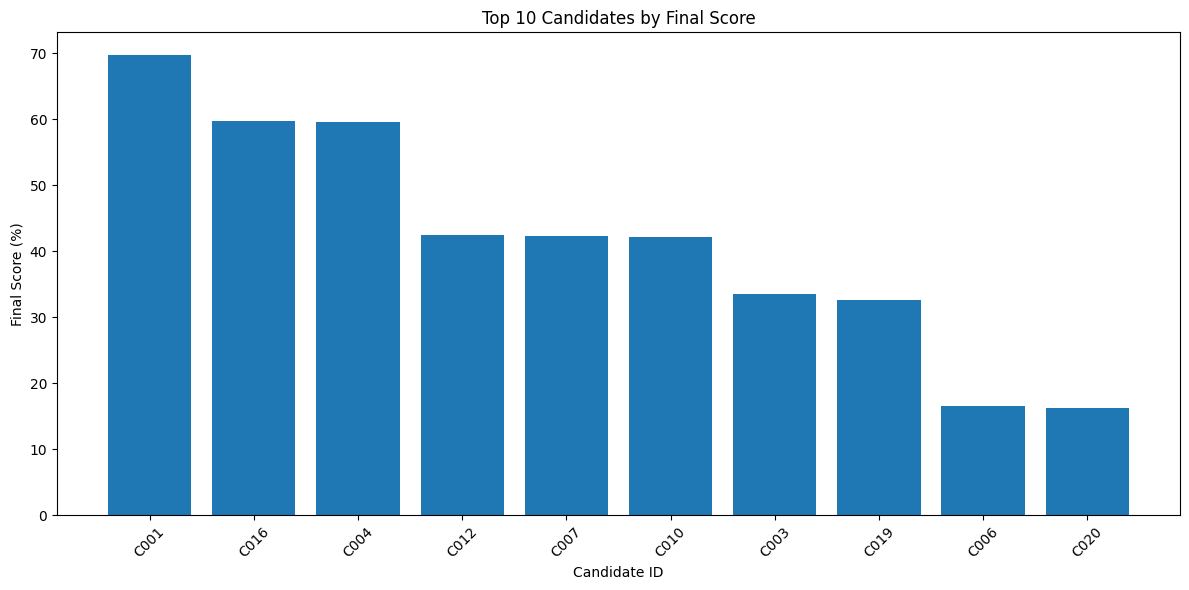

In [30]:
plt.figure(figsize=(12,6))

plt.bar(
    top_10['Candidate_ID'],
    top_10['Final_Score']
)

plt.title("Top 10 Candidates by Final Score")
plt.xlabel("Candidate ID")
plt.ylabel("Final Score (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

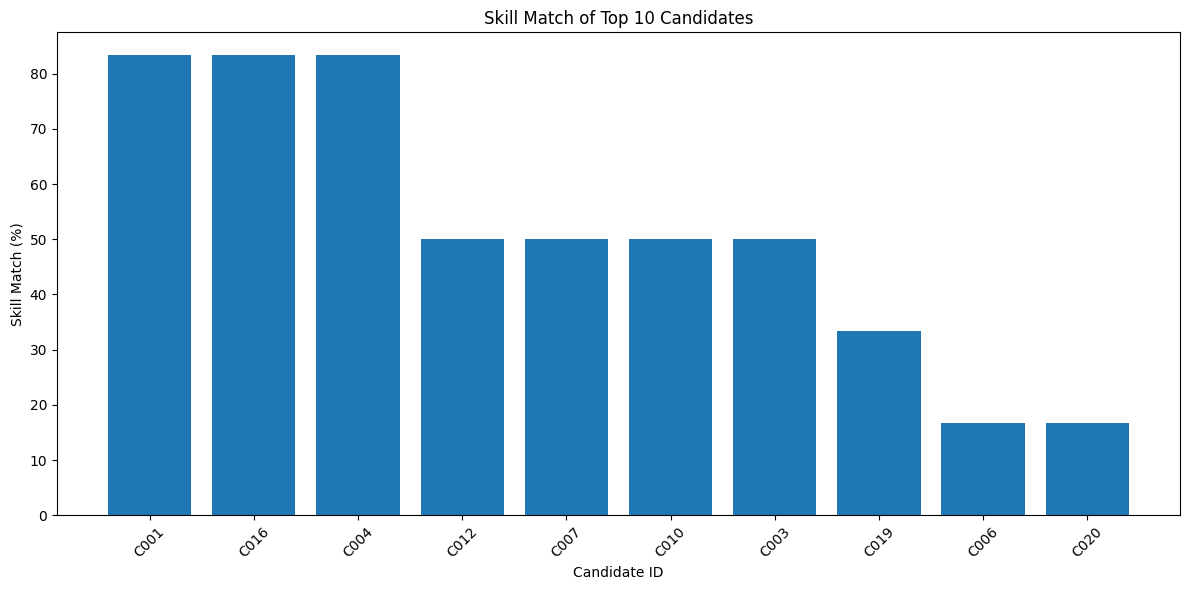

In [31]:
plt.figure(figsize=(12,6))

plt.bar(
    top_10['Candidate_ID'],
    top_10['Skill_Match']
)

plt.title("Skill Match of Top 10 Candidates")
plt.xlabel("Candidate ID")
plt.ylabel("Skill Match (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

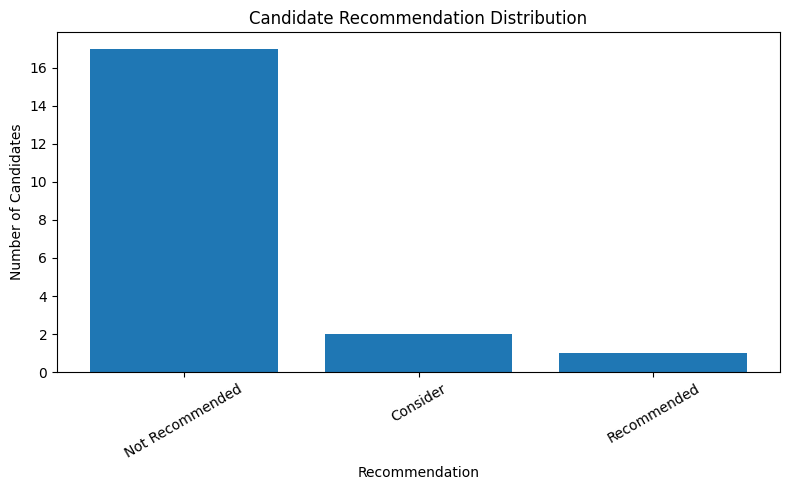

In [32]:
recommendation_counts = (
    resume_df['Recommendation']
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    recommendation_counts.index,
    recommendation_counts.values
)

plt.title("Candidate Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

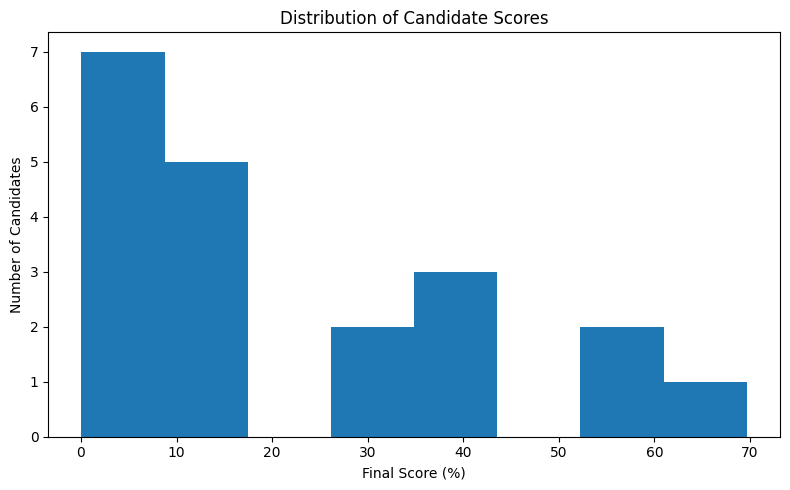

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    resume_df['Final_Score'],
    bins=8
)

plt.title("Distribution of Candidate Scores")
plt.xlabel("Final Score (%)")
plt.ylabel("Number of Candidates")

plt.tight_layout()
plt.show()

In [34]:
skill_counts = {}

for skill in required_skills:
    count = resume_df['Clean_Resume'].apply(
        lambda x: skill in x
    ).sum()

    skill_counts[skill] = count


skill_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=['Skill', 'Candidates_Matching']
)

display(skill_df)

,Skill,Candidates_Matching
0,recruitment,8
1,talent acquisition,3
2,employee engagement,4
3,employee relations,3
4,hr analytics,4
5,excel,14


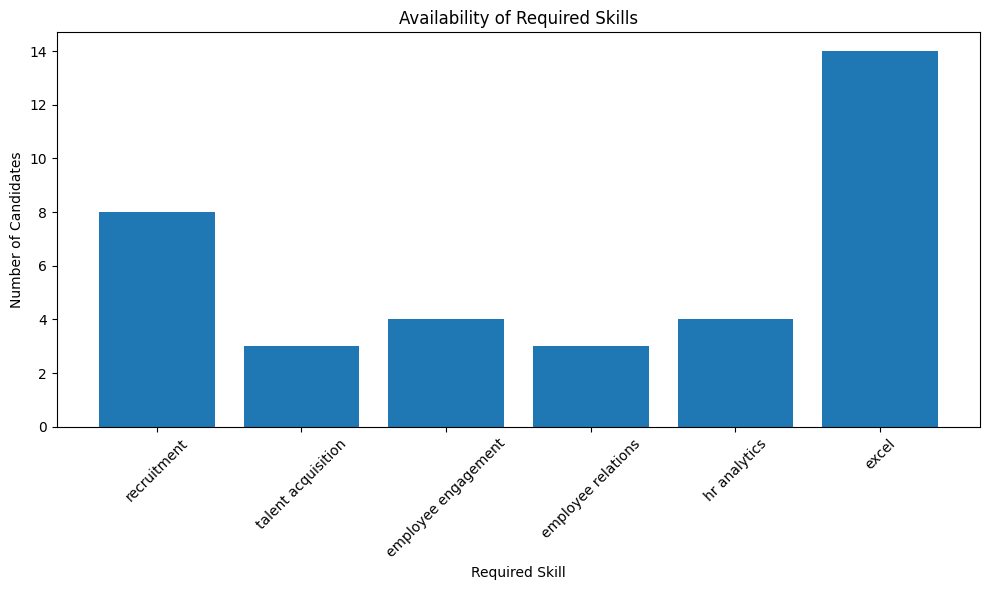

In [35]:

plt.figure(figsize=(10,6))

plt.bar(
    skill_df['Skill'],
    skill_df['Candidates_Matching']
)

plt.title("Availability of Required Skills")
plt.xlabel("Required Skill")
plt.ylabel("Number of Candidates")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [36]:
shortlisted = final_results[
    final_results['Final_Score'] >= 65
].copy()

print("Number of shortlisted candidates:",
      len(shortlisted))

display(shortlisted)

Number of shortlisted candidates: 1


,Rank,Candidate_ID,Category,Skill_Match,Matched_Skills,Experience_Score,Education_Score,Certification_Score,Similarity_Score,Final_Score,Recommendation
0,1,C001,HR Executive,83.333333,"recruitment, talent acquisition, employee enga...",0,100,100,59.865332,69.66,Recommended


In [37]:
output_file = 'Final_Resume_Screening_Results.csv'

final_results.to_csv(
    output_file,
    index=False
)

print("File created successfully:")
print(output_file)

File created successfully:
Final_Resume_Screening_Results.csv


In [38]:
shortlist_file = 'Shortlisted_Candidates.csv'

shortlisted.to_csv(
    shortlist_file,
    index=False
)

print("Shortlist file created successfully:")
print(shortlist_file)

Shortlist file created successfully:
Shortlisted_Candidates.csv


In [39]:
files.download('Final_Resume_Screening_Results.csv')

files.download('Shortlisted_Candidates.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
print("=" * 60)
print("SMART RESUME SCREENING & CANDIDATE RANKING SYSTEM")
print("=" * 60)

print("\nJob Position:", selected_job['Job_Title'])

print("Total Resumes Screened:", len(resume_df))

print(
    "Shortlisted Candidates:",
    len(shortlisted)
)

print(
    "Average Candidate Score:",
    round(resume_df['Final_Score'].mean(), 2),
    "%"
)

print(
    "Top Candidate:",
    final_results.iloc[0]['Candidate_ID']
)

print(
    "Top Candidate Score:",
    final_results.iloc[0]['Final_Score'],
    "%"
)

print("\nRequired Skills:")
for skill in required_skills:
    print("-", skill)

print("\nProject completed successfully!")

SMART RESUME SCREENING & CANDIDATE RANKING SYSTEM

Job Position: HR Executive
Total Resumes Screened: 20
Shortlisted Candidates: 1
Average Candidate Score: 25.21 %
Top Candidate: C001
Top Candidate Score: 69.66 %

Required Skills:
- recruitment
- talent acquisition
- employee engagement
- employee relations
- hr analytics
- excel

Project completed successfully!
